# **Online Advertising Performance Data**

## Objectives

* Find a dataset on Kaggle, set a goal for possible business insights, present the dataset in graphs or charts, explain and document my findings.

* Searching on Kaggle I have found three examples of datasets that match my interest and what I'd like to research into, social analytics. The examples are Social Media User Analysis, Social Media Engagment and Online Advertising Digital Marketing Data. I have chose to do the Online Advertising as it matched with what I believe would be a good start to understand working with AI as an assistant and datasets.

* My objective is to create two charts for the two campaigns, a pie chart showcasing what was more engaging out of Banners, Displays and Clicks. Followed by a line chart showcasing the campaigns and their progress of customer engagment within three months.

## Inputs & Outputs
 
* I have asked Chatgpt to generate codes that could work and if it didn't, Copilot's 'fix' option was very useful.

* Commenting (#) in the code markdowns was very useful for workflow as I written down/prompted what I wanted to see, Copilot has read the comment like predictive text. However if the title of the graph/charts wasn't right it was easy to fix, thanks to it's clear coding capability. 

* I had come across a problem where there was no further information for Campaign 2, I asked Chatgpt & Gemini to inspect the dataset. Not only did I get two answers that were informative but I was surprised there was no further documentation for Campaign 2 after April.

* When generating the pie charts it was my assumption that Copliot would put them in one image and not create three seperate images for two campaigns. Next time I will ask Chatgpt or Gemini for codes, so that I could have one image for each campaign and not take up space in the notebook with multiple insights to mention.

## Additional Comments

* This is a dataset found on Kaggle, created by N. Aniruddan.



---

# Change working directory

* Confirming work directory.

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PC\\Documents\\vs_code\\Unit1_Resub_Online_Marketing\\Unit1_Resub_Digital_Marketing\\jupyter_notebooks'

* Confirming os.path

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PC\\Documents\\vs_code\\Unit1_Resub_Online_Marketing\\Unit1_Resub_Digital_Marketing'

# Section 1

Section 1 content

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

# Section 2

Section 2 content

In [5]:
# read online_advertising_performance_data.csv
# Resolve the CSV path robustly so it works from the notebook folder or project folder
csv_filename = "online_advertising_performance_data.csv"

# Start from the known project folder
csv_path = os.path.join(current_dir, csv_filename)

# If not found there, check common fallback locations
if not os.path.exists(csv_path):
    candidate_paths = [
        os.path.join(os.getcwd(), csv_filename),
        os.path.join(os.path.dirname(current_dir), csv_filename),
        os.path.join(current_dir, "jupyter_notebooks", csv_filename),
    ]

    for candidate in candidate_paths:
        if os.path.exists(candidate):
            csv_path = candidate
            break
    else:
        # Final fallback: search the current folder tree
        for root, _, files in os.walk(os.getcwd()):
            if csv_filename in files:
                csv_path = os.path.join(root, csv_filename)
                break
        else:
            raise FileNotFoundError(
                f"Could not find '{csv_filename}'. "
                "Place it in the project folder or notebook folder."
            )

csv_path = os.path.abspath(csv_path)

if not os.path.exists(csv_path):
    candidate_paths = [
        os.path.join(os.getcwd(), os.path.basename(csv_path)),
        os.path.join(os.path.dirname(os.getcwd()), os.path.basename(csv_path))
    ]

    for candidate in candidate_paths:
        if os.path.exists(candidate):
            csv_path = candidate
            break
    else:
        for root, _, files in os.walk(os.getcwd()):
            if os.path.basename(csv_path) in files:
                csv_path = os.path.join(root, os.path.basename(csv_path))
                break
        else:
            raise FileNotFoundError(
                f"Could not find '{os.path.basename(csv_path)}'. "
                "Place it in the same folder as the notebook or project folder."
            )

df = pd.read_csv(csv_path)
df.head()


,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000,NaN,NaN
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602,NaN,NaN
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636,NaN,NaN
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234,NaN,NaN
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000,NaN,NaN


After looking through the dataset I can see two columns that have no value (Missing Value) and Unnamed 12 & 13, these two columns shall be removed. There are three campaigns instead of two, this will be interesting to now see which one of the three was more engaging.

While the goal is to concentrate on engagment, I noticed the User Engagment column has verbal (?) values such as High, Low and Medium.

In [6]:
# remove columns 'Unnamed: 12' and 'Unnamed: 13' from the dataframe
df = df.drop(columns=['Unnamed: 12', 'Unnamed: 13'], errors='ignore')
df_cleaned = df.dropna(axis=1)
df_cleaned
df.head()

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000


I can see that the unnamed columns have been removed and has also NOT changed any of the other columns and their values.

A previouse attempt to save this cleaned dataset resulted in values being changed such as User Engagment was "highhighhigh", "lowlowlow" and "mediummediummedium". This time I will see if I can just reference "df_cleaned" as apposed to have two csv files in the notebook.

In [7]:
# show df_cleaned
df_cleaned

,month,day,campaign_number,user_engagement,banner,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount
0,April,1,camp 1,High,160 x 600,4,0.0060,0,0.0000,0,0.0000
1,April,1,camp 1,High,160 x 600,20170,26.7824,158,28.9717,23,1972.4602
2,April,1,camp 1,High,160 x 600,14701,27.6304,158,28.9771,78,2497.2636
3,April,1,camp 1,High,160 x 600,171259,216.8750,1796,329.4518,617,24625.3234
4,April,1,camp 1,Low,160 x 600,552,0.0670,1,0.1834,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
15403,April,1,camp 1,Low,160 x 600,16,0.0249,0,0.0000,0,0.0000
15404,April,1,camp 1,Low,160 x 600,2234,0.4044,10,1.8347,3,101.7494
15405,June,29,camp 1,High,800 x 250,1,0.0157,0,0.0000,0,0.0000
15406,June,29,camp 1,High,800 x 250,4,0.0123,0,0.0000,0,0.0000


After a brief test of just asking Copilot to "show df_cleaned", I can see the that the two unnamed columns with 'Missing Values' have not appeared, no repeating values in User Engagment and although having noticed that the dataset is reading slightly larger than the first read/Iteration, looking at the information in Data Wrangler I can see nothing major that could break (fingers crossed).

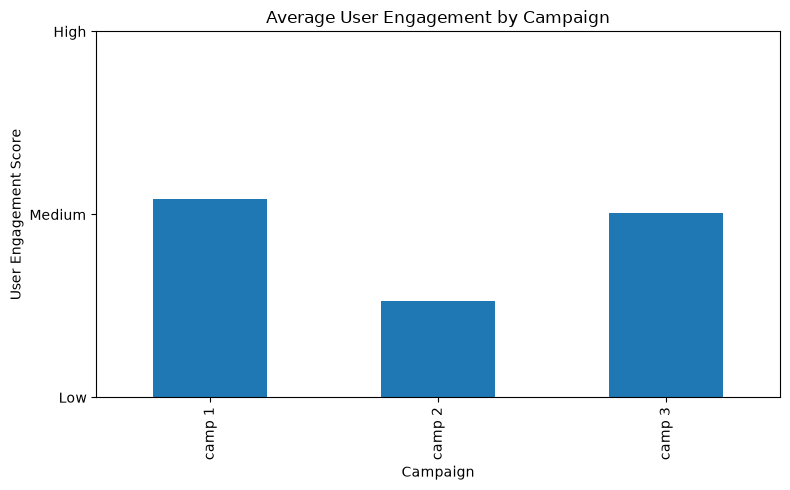

In [8]:
# from df_cleaned can you show me a bar chart for User_Engagement for camp 1, camp 2, and camp 3
# Map engagement labels to numeric values so the chart can plot
engagement_map = {'Low': 1, 'Medium': 2, 'High': 3}

campaign_df = df_cleaned[
    df_cleaned['campaign_number'].isin(['camp 1', 'camp 2', 'camp 3'])
].copy()

campaign_df['engagement_score'] = campaign_df['user_engagement'].map(engagement_map)

# Average engagement score per campaign
campaign_summary = (
    campaign_df.groupby('campaign_number', as_index=False)['engagement_score']
    .mean()
    .rename(columns={'engagement_score': 'avg_user_engagement'})
)

campaign_summary.plot(
    x='campaign_number',
    y='avg_user_engagement',
    kind='bar',
    legend=False,
    figsize=(8, 5)
)

plt.title('Average User Engagement by Campaign')
plt.xlabel('Campaign')
plt.ylabel('User Engagement Score')
plt.ylim(1, 3)
plt.yticks([1, 2, 3], ['Low', 'Medium', 'High'])
plt.tight_layout()
plt.show()


Brilliant! The User Engagment values has not been broken, however I realise that the campaigns ran for three months and I haven't asked Copilot to show a month (April, May & June). 

I did ask Chatgpt "what is the best chart for verbal values of high, low and medium?" and got this response.

If your data consists of verbal categories — High, Medium, Low — the best chart is usually a bar chart.

* Bar chart: Best for clearly comparing how many items fall into High, Medium, and Low.
* Stacked bar: Good if you want to show High/Medium/Low as proportions within different groups.
* Pie/donut chart: Useful if you only want to show the overall percentage split, but harder to compare precisely.

I shall keep this answer here as I think this is a good response to reference during the project, I am aware that any AI engine (Copilot, Chatgpt & Gemini) should be utilised as a tool that suggests and makes recommendations with the right prompts/requests and should not be gospel. Then I believe user enterpretation should be considered as pictured (Graphed) above I have asked for UE for each campaign, though I'm happy with the result I did not account for time (Months).

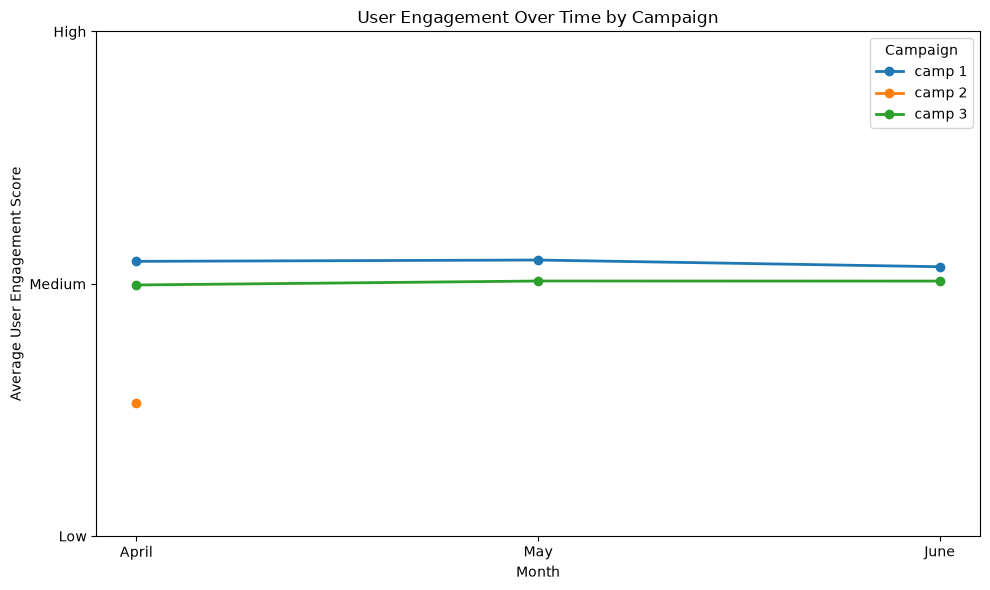

In [9]:
# show me a line chart of User Engagement over time for camp 1, camp 2, and camp 3. between months April and June. Use the month column for the x-axis and the user_engagement column for the y-axis. Use different colors for each campaign and include a legend.
#generate a line chart of User Engagement over time for camp 1, camp 2, and camp 3 between months April and June. Use the month column for the x-axis and the user_engagement column for the y-axis. Use different colors for each campaign and include a legend.
# Filter the dataframe for the specified campaigns and months
campaign_month_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 2', 'camp 3'])) &
    (df_cleaned['month'].isin(['April', 'May', 'June']))
] 
# generate campaign_month_df with the average user engagement for each campaign and month
# Map engagement labels to numeric values so the chart can plot on a meaningful scale
engagement_map = {'Low': 1, 'Medium': 2, 'High': 3}
campaign_month_df = campaign_month_df.copy()
campaign_month_df['engagement_score'] = campaign_month_df['user_engagement'].map(engagement_map)

# Average engagement score by campaign and month
campaign_month_summary = (
    campaign_month_df.groupby(['campaign_number', 'month'], as_index=False)['engagement_score']
    .mean()
    .rename(columns={'engagement_score': 'avg_user_engagement'})
)

# Keep month order consistent for the chart
campaign_month_summary['month'] = pd.Categorical(
    campaign_month_summary['month'],
    categories=['April', 'May', 'June'],
    ordered=True
)
campaign_month_summary = campaign_month_summary.sort_values(['campaign_number', 'month'])

# Plot each campaign as its own line
plt.figure(figsize=(10, 6))

for campaign in ['camp 1', 'camp 2', 'camp 3']:
    subset = campaign_month_summary[campaign_month_summary['campaign_number'] == campaign]
    plt.plot(
        subset['month'],
        subset['avg_user_engagement'],
        marker='o',
        linewidth=2,
        label=campaign
    )

plt.title('User Engagement Over Time by Campaign')
plt.xlabel('Month')
plt.ylabel('Average User Engagement Score')
plt.ylim(1, 3)
plt.yticks([1, 2, 3], ['Low', 'Medium', 'High'])
plt.legend(title='Campaign')
plt.tight_layout()
plt.show()


Interesting, I have asked Copliot to generate a line chart instead of a bar because it would present change over time. However I noticed for Camp 2 in May & June there wasn't anything on the scale.

Upon asking for different iterations of code, charts and searching through Data Wrangler I asked Chatgpt "For camp 2, does the user engagement go past April?" With the original csv file for the AI to reference and read through. AI's response was "No. For Camp 2, the dataset only contains April data."

For a second opinion I asked Gemini the same question and got this response 
"No, user engagement for camp 2 does not go past April.

In the dataset:
* camp 2 only has records in April (1,614 total entries, split between Low and Medium engagement).
* There are 0 records for camp 2 in May or June (whereas camp 1 and camp 3 continue through both May and June)."

Not only did Gemini predict my next question (What about Camp 1 & 3?) but gave me that extra detail in the response. As one of the objectives is to report user engagment for each campaign, the 'User Egagment' column is only good for Camp 2 in April. Thus making 1 & 3 redundant, however I belive there can still be that interaction found in the campaigns through 'Clicks, Conversion Rates and Post Click Conversions" 

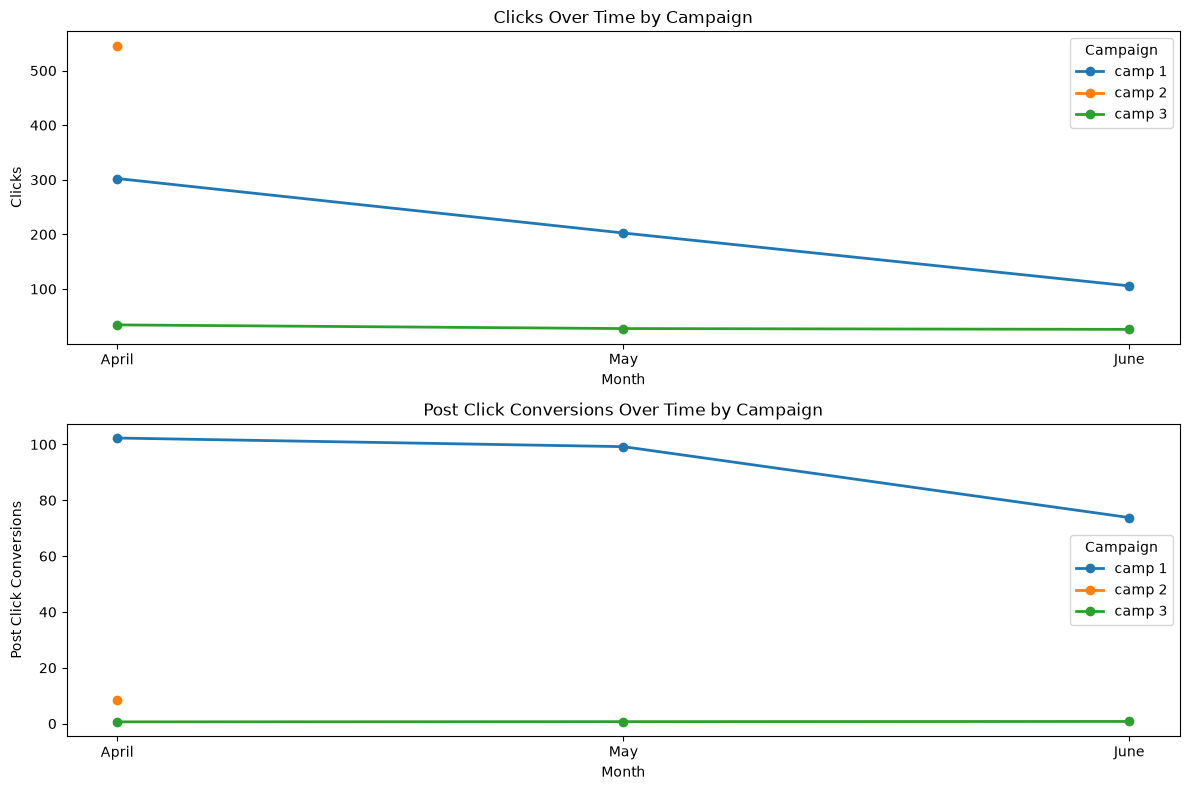

In [10]:
#generate a line chart of Clicks, Conversion Rates and Post Click Conversions for camp 1, camp 2, and camp 3 between months April and June. Use the month column for the x-axis and the Clicks, Conversion Rates and Post Click Conversions columns for the y-axis. Use different colors for each campaign and include a legend.
# Filter the dataframe for the specified campaigns and months
campaign_metrics_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 2', 'camp 3'])) &
    (df_cleaned['month'].isin(['April', 'May', 'June']))
]

#generate a line chart for Clicks, Conversion Rates and Post Click Conversions for camp 1, camp 2, and camp 3 between months April and June. Use the month column for the x-axis and the Clicks, Conversion Rates and Post Click Conversions columns for the y-axis. Use different colors for each campaign and include a legend.
# avarage Clicks, Conversion Rates and Post Click Conversions by campaign and month
campaign_metrics_summary = (
    campaign_metrics_df.groupby(['campaign_number', 'month'], as_index=False)[['clicks', 'post_click_conversions']]
    .mean()
)
# Keep month order consistent for the chart
campaign_metrics_summary['month'] = pd.Categorical(
    campaign_metrics_summary['month'],
    categories=['April', 'May', 'June'],
    ordered=True
)
campaign_metrics_summary = campaign_metrics_summary.sort_values(['campaign_number', 'month'])
# Plot each campaign as its own line for each metric
plt.figure(figsize=(12, 8))
metrics = ['clicks', 'post_click_conversions']
for metric in metrics:
    plt.subplot(2, 1, metrics.index(metric) + 1)
    for campaign in ['camp 1', 'camp 2', 'camp 3']:
        subset = campaign_metrics_summary[campaign_metrics_summary['campaign_number'] == campaign]
        plt.plot(
            subset['month'],
            subset[metric],
            marker='o',
            linewidth=2,
            label=campaign
        )
    plt.title(f'{metric.replace("_", " ").title()} Over Time by Campaign')
    plt.xlabel('Month')
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend(title='Campaign')
    plt.tight_layout()

Interesting again! I have now asked Chatgpt and Gemini "Does any other value for camp 2 go past april?" both responses are "No, no other value or metric for camp 2 goes past April." This is still referring to the original dataset/csv file.

If I am to continue with this incomplete(?) dataset, I can always ask Copilot to generate charts for April. BUT for a business insight or even make predictive statements for Camp 2 would be unnecessary to present as I can see Camps 1 & 3 have been documented for three months.

I am intrigued as to see how the three campaigns performed in April so I will make a bar chart for that month, followed by campaigns 1 & 3 as a line chart for the three months as I wonder if it can be presented?

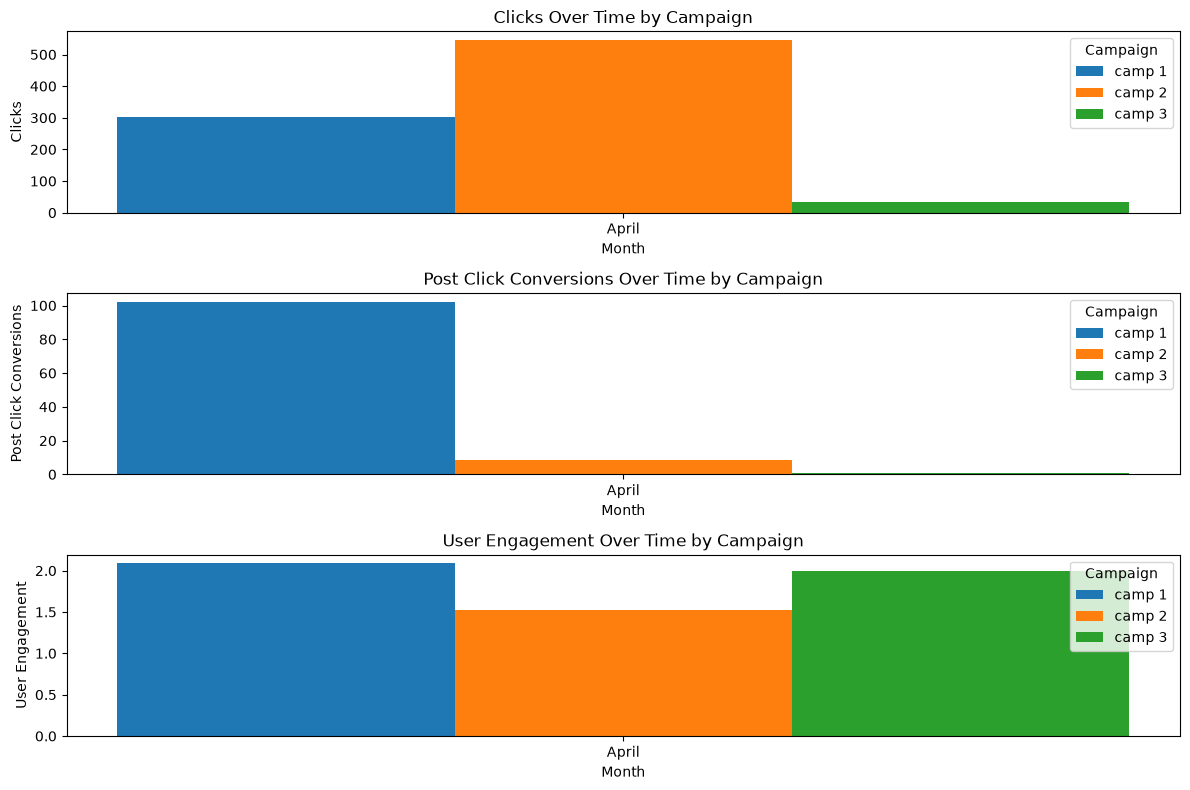

In [11]:
# generate a bar chart for clicks, post_click_conversions and user_engagement for camp 1, camp 2, and camp 3 for months April. Use the month column for the x-axis and the clicks, post_click_conversions and user_engagement columns for the y-axis. Use different colors for each campaign and include a legend.
# Filter the dataframe for the specified campaigns and months
campaign_metrics_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 2', 'camp 3'])) &
    (df_cleaned['month'].isin(['April']))
]
# generate campaign_metrics_df with the average clicks, post_click_conversions and user_engagement for each campaign and month
# Map engagement labels to numeric values so the chart can plot on a meaningful scale
engagement_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
campaign_metrics_df['user_engagement'] = campaign_metrics_df['user_engagement'].map(engagement_mapping)

# Average metrics by campaign and month
campaign_metrics_summary = (
    campaign_metrics_df.groupby(['campaign_number', 'month'], as_index=False)[['clicks', 'post_click_conversions', 'user_engagement']]
    .mean()
)
# Keep month order consistent for the chart
campaign_metrics_summary['month'] = pd.Categorical(
    campaign_metrics_summary['month'],
    categories=['April'],
    ordered=True
)
campaign_metrics_summary = campaign_metrics_summary.sort_values(['campaign_number', 'month'])
# Plot each campaign as its own bar for each metric
plt.figure(figsize=(12, 8))
# Set the width of the bars
bar_width = 0.2
# Set the positions of the bars on the x-axis
months = ['April']
x_positions = np.arange(len(months))
# Loop through each metric and plot the bars
for i, metric in enumerate(['clicks', 'post_click_conversions', 'user_engagement']):
    plt.subplot(3, 1, i + 1)
    for j, campaign in enumerate(['camp 1', 'camp 2', 'camp 3']):
        subset = campaign_metrics_summary[campaign_metrics_summary['campaign_number'] == campaign]
        plt.bar(
            x_positions + j * bar_width,
            subset[metric],
            width=bar_width,
            label=campaign
        )
    plt.title(f'{metric.replace("_", " ").title()} Over Time by Campaign')
    plt.xlabel('Month')
    plt.ylabel(metric.replace("_", " ").title())
    plt.xticks(x_positions + bar_width, months)
    plt.legend(title='Campaign')
    plt.tight_layout()


Commenting in the code markdowns for Copilot, I wondered why I seen April, May and June? I then realised I only wanted to look at one month, I noticed this because camp 2 suddenly had, not just values but the same values for three months. Thankfully that was easy to recognise due to asking Chatgpt & Gemini earlier for further values.

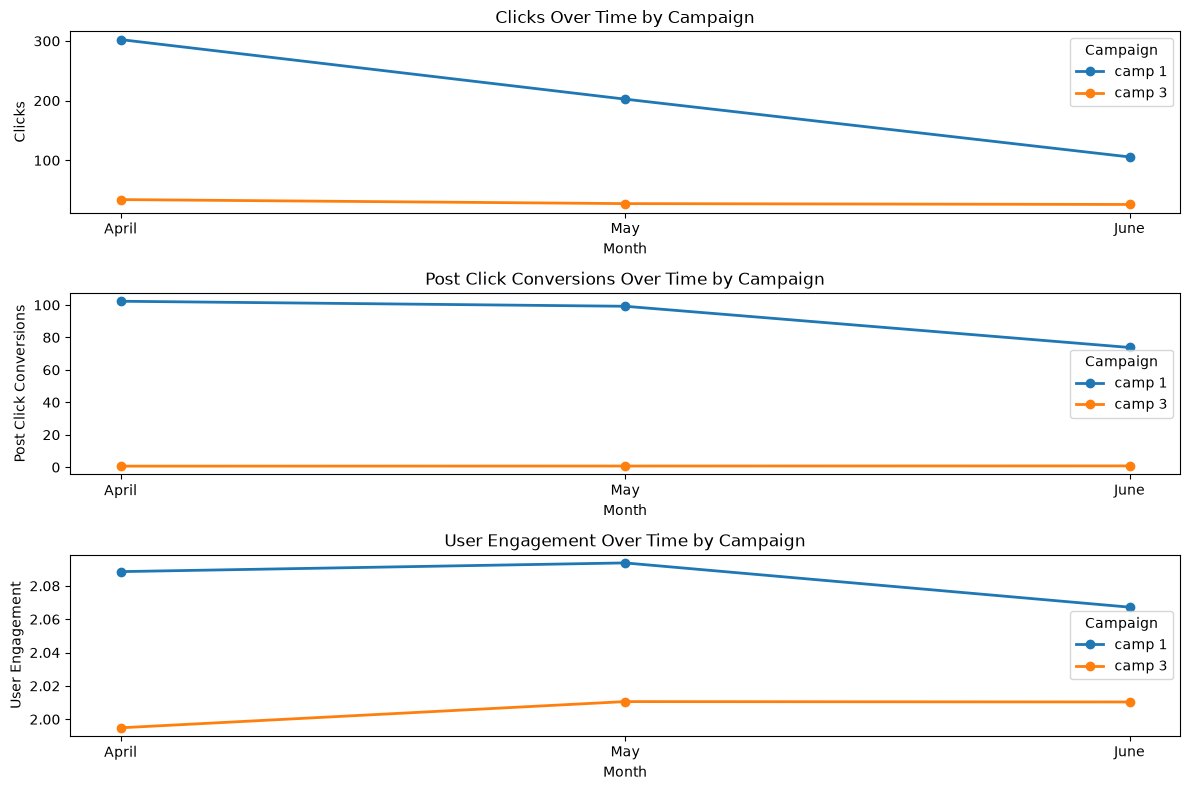

In [12]:
# generate a line chart for clicks, post_click_conversions and user_engagement for camp 1 and camp 3 between months April and June. Use the month column for the x-axis and the clicks, post_click_conversions and user_engagement columns for the y-axis. Use different colors for each campaign and include a legend.
# Filter the dataframe for the specified campaigns and months
campaign_metrics_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 3'])) &
    (df_cleaned['month'].isin(['April', 'May', 'June']))
]
# Map engagement labels to numeric values so the chart can plot on a meaningful scale
engagement_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
campaign_metrics_df['user_engagement'] = campaign_metrics_df['user_engagement'].map(engagement_mapping)
# Average metrics by campaign and month
campaign_metrics_summary = (
    campaign_metrics_df.groupby(['campaign_number', 'month'], as_index=False)[['clicks', 'post_click_conversions', 'user_engagement']]
    .mean()
)
# Keep month order consistent for the chart
campaign_metrics_summary['month'] = pd.Categorical(
    campaign_metrics_summary['month'],
    categories=['April', 'May', 'June'],
    ordered=True
)
campaign_metrics_summary = campaign_metrics_summary.sort_values(['campaign_number', 'month'])
# Plot each campaign as its own line for each metric
plt.figure(figsize=(12, 8))
for i, metric in enumerate(['clicks', 'post_click_conversions', 'user_engagement']):
    plt.subplot(3, 1, i + 1)
    for campaign in ['camp 1', 'camp 3']:
        subset = campaign_metrics_summary[campaign_metrics_summary['campaign_number'] == campaign]
        plt.plot(
            subset['month'],
            subset[metric],
            marker='o',
            linewidth=2,
            label=campaign
        )
    plt.title(f'{metric.replace("_", " ").title()} Over Time by Campaign')
    plt.xlabel('Month')
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend(title='Campaign')
    plt.tight_layout()

This definitely looks presentable and more reliable now that camp 2 has been not icluded, I do feel conflicted passing it off as just "Due to no further documentation, I'm unable to continue with Campaign 2". Finding out 'best out of the three' would have been interesting but it is now 'best out of the two'.

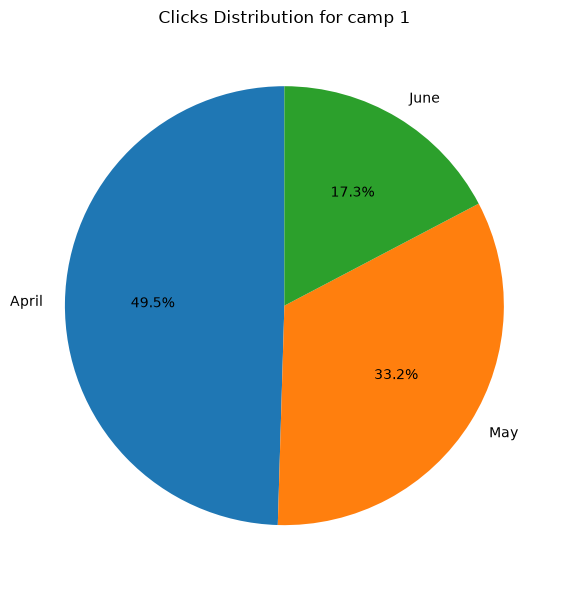

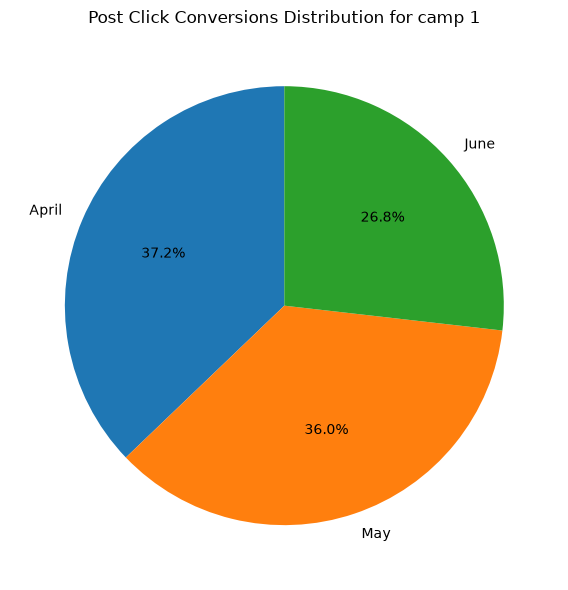

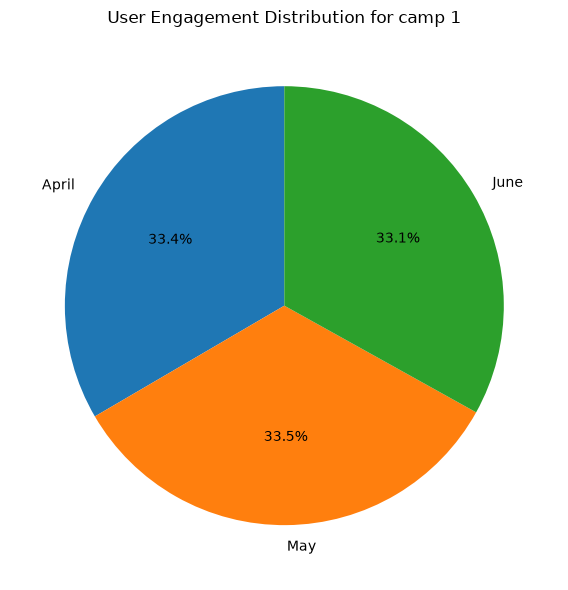

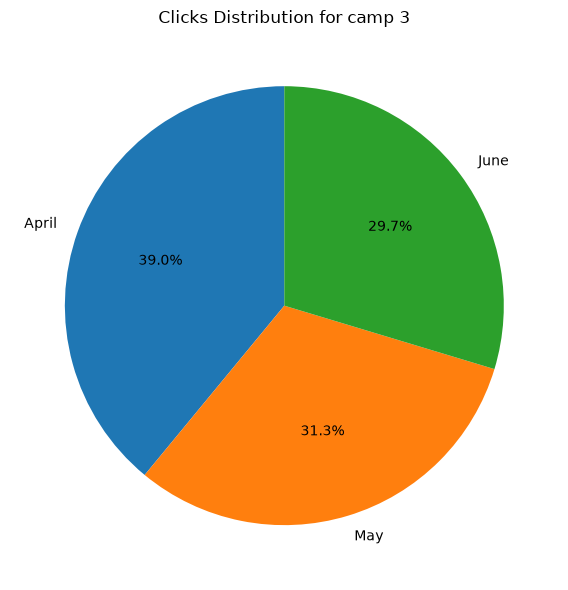

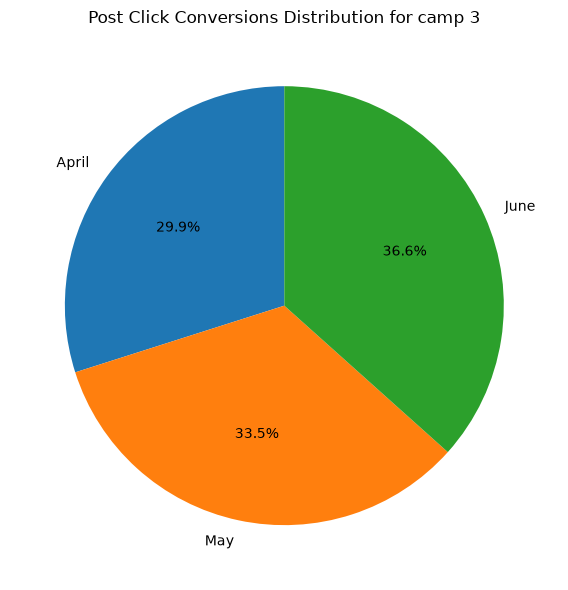

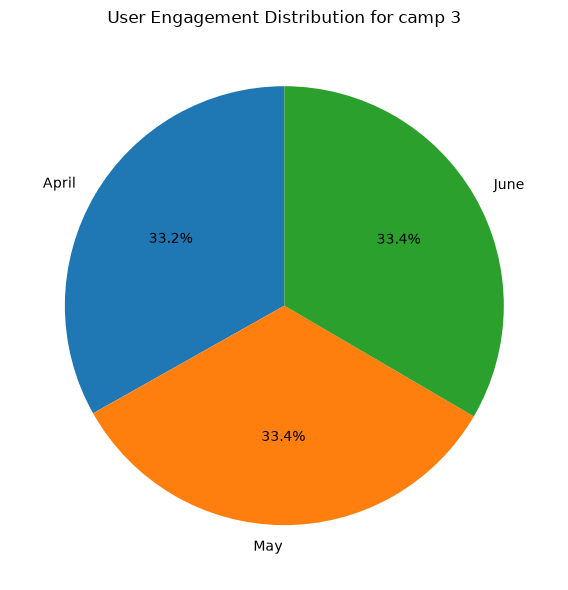

In [13]:
# generate seperate pie chart for camp 1 and camp 3 for clicks, post_click_conversions and user_engagment for months April, May and June.
# Filter the dataframe for the specified campaigns and months
campaign_metrics_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 3'])) &
    (df_cleaned['month'].isin(['April', 'May', 'June']))
]
# Map engagement labels to numeric values so the chart can plot on a meaningful scale
engagement_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
campaign_metrics_df['user_engagement'] = campaign_metrics_df['user_engagement'].map(engagement_mapping)
# Average metrics by campaign and month
campaign_metrics_summary = (
    campaign_metrics_df.groupby(['campaign_number', 'month'], as_index=False)[['clicks', 'post_click_conversions', 'user_engagement']]
    .mean()
)
# Keep month order consistent for the chart
campaign_metrics_summary['month'] = pd.Categorical(
    campaign_metrics_summary['month'],
    categories=['April', 'May', 'June'],
    ordered=True
)
campaign_metrics_summary = campaign_metrics_summary.sort_values(['campaign_number', 'month'])
# Generate separate pie charts for camp 1 and camp 3 for clicks, post_click_conversions, and user_engagement for months April, May, and June
for campaign in ['camp 1', 'camp 3']:
    subset = campaign_metrics_summary[campaign_metrics_summary['campaign_number'] == campaign]
    for metric in ['clicks', 'post_click_conversions', 'user_engagement']:
        plt.figure(figsize=(6, 6))
        plt.pie(
            subset[metric],
            labels=subset['month'],
            autopct='%1.1f%%',
            startangle=90
        )
        plt.title(f'{metric.replace("_", " ").title()} Distribution for {campaign}')
        plt.tight_layout()
        plt.show()

As much as I love pie charts, there is a lot to present indivdually because within these charts are the campaigns (1&3), followed by Clicks, Post Click Conversions, User Engagment and finally the months within each of those aspects.

Not only is there a lot to present but I can see a slight confusion, you have to read the pie chart anti clockwise. This I think would confuse an audience both technical & non-technical and also if it were used for research or business enquiry, as I now believe the Bar & Line charts are better for presenting scale of time (Years, Month & Days). I'm happy testing the pie charts as I can see the percentage of values but maybe save them for projects that don't require time frames.

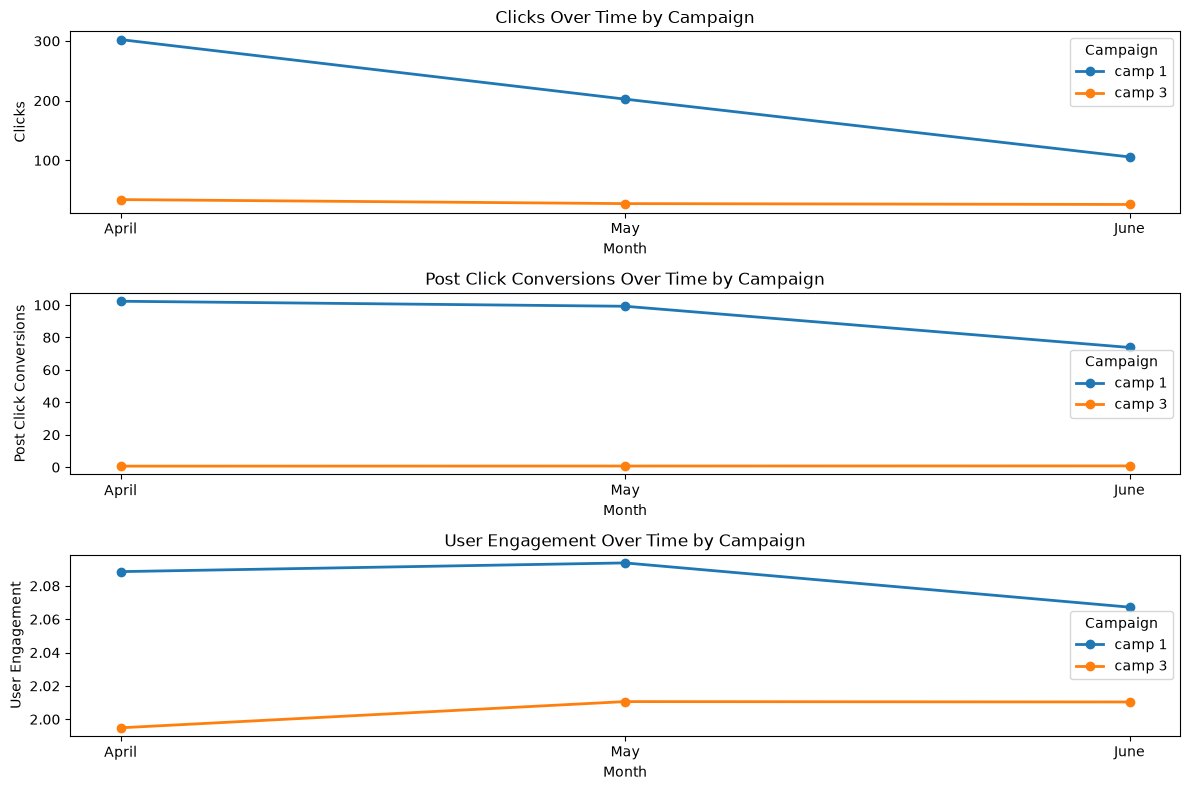

In [14]:

campaign_metrics_df = df_cleaned[
    (df_cleaned['campaign_number'].isin(['camp 1', 'camp 3'])) &
    (df_cleaned['month'].isin(['April', 'May', 'June']))
]

engagement_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
campaign_metrics_df['user_engagement'] = campaign_metrics_df['user_engagement'].map(engagement_mapping)

campaign_metrics_summary = (
    campaign_metrics_df.groupby(['campaign_number', 'month'], as_index=False)[['clicks', 'post_click_conversions', 'user_engagement']]
    .mean()
)

campaign_metrics_summary['month'] = pd.Categorical(
    campaign_metrics_summary['month'],
    categories=['April', 'May', 'June'],
    ordered=True
)
campaign_metrics_summary = campaign_metrics_summary.sort_values(['campaign_number', 'month'])

plt.figure(figsize=(12, 8))
for i, metric in enumerate(['clicks', 'post_click_conversions', 'user_engagement']):
    plt.subplot(3, 1, i + 1)
    for campaign in ['camp 1', 'camp 3']:
        subset = campaign_metrics_summary[campaign_metrics_summary['campaign_number'] == campaign]
        plt.plot(
            subset['month'],
            subset[metric],
            marker='o',
            linewidth=2,
            label=campaign
        )
    plt.title(f'{metric.replace("_", " ").title()} Over Time by Campaign')
    plt.xlabel('Month')
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend(title='Campaign')
    plt.tight_layout()

# Results for Best Advertising Campaign.

From April to June Campaign 1 has had a steady decline in the Clicks segment but has strong UE (User Engagment) and PCC (Post Click Conversion) for two months. Campaign 3 has got steady results in Clicks and PCC, there is also a significant rise in UE.

Overall we can see Campaign 1 is the winner! With very high marks in PCC & UE, the decline in Clicks is possibly to be expected for an advertising campaign. 

My consideration for this result and project is, without knowing what was being advertised, who the target audience was. I don't think location matters as long as it's online, although I suspect it would be beneficial to know geographical locations and also which media (Facebook, X, Instagram) got the most conversions.

---

# Conclusion & Next Steps.

* I did think commenting with the '#' in the code markdowns was very useful as Copilot read it like predictive text, alongside asking Copilot to generate codes and commands.

* Chatgpt was useful for questions like "Can you generate codes for ... to work in Vscode?" Because it would give more than two examples. Then I could either put the code in the markdowns and Copilot could also fix it (If the code didn't work from Chatgpt) or just simply ask (Comment) Copilot to generate the code and the option to be inserted into the markdown made the work easier... BUT I did have to make sure it was presentable and what I wanted.

* Chatgpt & Gemini were very helpful when finding out there was no further documentation for Campaign 2 after April, I thought it was just the User Engagment that was missing values for the two months but it turned out to be all of them. I did want to make sure I got a second opinion as I think it's wise to not rely on just one generative AI system, as the answer could be different slightly and that was the case earlier.

* As mentioned before I chose NOT to save the 'df_cleaned' as a new dataset/csv file due to values breaking or repeating (highhighhigh). I can see that just referring to 'df_cleaned' worked, as I did not see the Unnamed columns 12 & 13 and no missing values.

* Next time I will research and prepare which charts I wish to use, as I mentioned before and looked up the pros & cons of using pie charts, showing change over time is one of the cons that I was concerned about. I will definitely be using Bar & Line charts again, as they presented more on a measureable scale and progress over time.